# Goal:
## 1. Clean and validate transaction and customer data
## 2. Identify key customer purchasing behaviours
## 3. Find the most valuable customer segments
## 4. Provide commercial recommendations

# Quantium Task 1: Data Preparation and Customer Analytics

## 1. Import libraries and load datasets

In [73]:
import pandas as pd
import numpy as np
from IPython.core.interactiveshell import InteractiveShell

# Set the shell to show all outputs, not just the last one
InteractiveShell.ast_node_interactivity = "all"

txn = pd.read_excel("QVI_transaction_data.xlsx")
cust = pd.read_csv("QVI_purchase_behaviour.csv")

The transaction dataset (`txn`) and customer dataset (`cust`) were loaded successfully.

- `txn` contains transaction-level data
- `cust` contains customer profile information

## 2. Initial data inspection

In [ ]:
txn.info()
cust.info()

## 3. Missing value check

In [18]:
txn.isna().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [8]:
cust.isna().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

## 4. Duplicate check

In [9]:
txn.duplicated().sum()

np.int64(1)

In [19]:
txn[txn.duplicated(keep=False)]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
124843,2018-10-01,107,107024,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.0
124845,2018-10-01,107,107024,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.0


In [20]:
txn = txn.drop_duplicates()

After removing duplicates, the transaction dataset contains no duplicated rows.

In [21]:
cust.duplicated().sum()

np.int64(0)

In [22]:
cust.duplicated().sum()

np.int64(0)

## 5. Preview the datasets

In [23]:
txn.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [24]:
cust.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


## 6. Check and convert the date column

In [25]:
txn["DATE"].head()

0   2018-10-17
1   2019-05-14
2   2019-05-20
3   2018-08-17
4   2018-08-18
Name: DATE, dtype: datetime64[us]

In [26]:
txn["DATE"].dtype

dtype('<M8[us]')

In [27]:
txn["DATE"].min(), txn["DATE"].max()

(Timestamp('2018-07-01 00:00:00'), Timestamp('2019-06-30 00:00:00'))

In [28]:
txn["MONTH"] = txn["DATE"].dt.to_period("M")
txn["MONTH"].value_counts().sort_index()

MONTH
2018-07    22562
2018-08    22411
2018-09    21743
2018-10    22287
2018-11    21852
2018-12    22835
2019-01    22161
2019-02    20405
2019-03    22592
2019-04    21766
2019-05    22392
2019-06    21829
Freq: M, Name: count, dtype: int64

A monthly summary was created to inspect whether transactions are distributed reasonably across the available time period.

In [29]:
txn[["DATE", "MONTH"]].head()

,DATE,MONTH
0,2018-10-17,2018-10
1,2019-05-14,2019-05
2,2019-05-20,2019-05
3,2018-08-17,2018-08
4,2018-08-18,2018-08


## 7. Inspect numerical columns

In [30]:
txn[["PROD_QTY", "TOT_SALES"]].describe()

,PROD_QTY,TOT_SALES
count,264835.000000,264835.000000
mean,1.907308,7.304205
std,0.643655,3.083231
min,1.000000,1.500000
25%,2.000000,5.400000
50%,2.000000,7.400000
75%,2.000000,9.200000
max,200.000000,650.000000


Summary statistics were checked for `PROD_QTY` and `TOT_SALES` to identify unusual values and better understand the range of transactions.

In [31]:
txn.sort_values("PROD_QTY", ascending=False).head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,MONTH
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.00,2018-08
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.00,2019-05
5363,2019-05-19,210,210087,209290,4,Dorito Corn Chp Supreme 380g,5,16.25,2019-05
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.00,2018-08
238395,2019-05-19,238,238250,242874,88,Kettle Honey Soy Chicken 175g,5,27.00,2019-05
5365,2018-08-19,210,210320,210294,3,Kettle Sensations Camembert & Fig 150g,5,23.00,2018-08
238471,2019-05-19,261,261331,261111,87,Infuzions BBQ Rib Prawn Crackers 110g,5,19.00,2019-05
228749,2019-05-19,232,232138,235978,109,Pringles Barbeque 134g,5,18.50,2019-05
228711,2018-08-17,205,205149,204215,1,Smiths Crinkle Cut Chips Barbecue 170g,5,14.50,2018-08
32696,2019-05-17,208,208177,207128,104,Infuzions Thai SweetChili PotatoMix 110g,5,19.00,2019-05


In [33]:
txn.sort_values("TOT_SALES", ascending=False).head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,MONTH
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0,2019-05
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0,2018-08
55558,2019-05-14,190,190113,190914,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5,2019-05
117850,2019-05-19,194,194308,194516,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5,2019-05
150683,2019-05-20,118,118021,120799,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5,2019-05
5179,2018-08-15,94,94148,93390,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5,2018-08
171815,2018-08-17,24,24095,20797,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5,2018-08
69496,2018-08-15,49,49303,45789,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5,2018-08
184969,2019-05-20,44,44350,40394,14,Smiths Crnkle Chip Orgnl Big Bag 380g,5,29.5,2019-05
135445,2018-08-14,154,154199,154279,20,Doritos Cheese Supreme 330g,5,28.5,2018-08


The highest transaction quantities and sales values were inspected to determine whether any extreme records may represent outliers or non-typical purchases.

## 8. Inspect product names

In [34]:
txn["PROD_NAME"].head(20)

0       Natural Chip        Compny SeaSalt175g
1                     CCs Nacho Cheese    175g
2       Smiths Crinkle Cut  Chips Chicken 170g
3       Smiths Chip Thinly  S/Cream&Onion 175g
4     Kettle Tortilla ChpsHny&Jlpno Chili 150g
5     Old El Paso Salsa   Dip Tomato Mild 300g
6     Smiths Crinkle Chips Salt & Vinegar 330g
7        Grain Waves         Sweet Chilli 210g
8      Doritos Corn Chip Mexican Jalapeno 150g
9        Grain Waves Sour    Cream&Chives 210G
10    Smiths Crinkle Chips Salt & Vinegar 330g
11       Kettle Sensations   Siracha Lime 150g
12                    Twisties Cheese     270g
13            WW Crinkle Cut      Chicken 175g
14              Thins Chips Light&  Tangy 175g
15                           CCs Original 175g
16                           Burger Rings 220g
17      NCC Sour Cream &    Garden Chives 175g
18     Doritos Corn Chip Southern Chicken 150g
19                    Cheezels Cheese Box 125g
Name: PROD_NAME, dtype: str

The product names were inspected to understand how product information is stored and to identify whether any cleaning or categorisation is required.

In [38]:
txn["PROD_NAME"].drop_duplicates().sort_values().tolist()

['Burger Rings 220g',
 'CCs Nacho Cheese    175g',
 'CCs Original 175g',
 'CCs Tasty Cheese    175g',
 'Cheetos Chs & Bacon Balls 190g',
 'Cheetos Puffs 165g',
 'Cheezels Cheese 330g',
 'Cheezels Cheese Box 125g',
 'Cobs Popd Sea Salt  Chips 110g',
 'Cobs Popd Sour Crm  &Chives Chips 110g',
 'Cobs Popd Swt/Chlli &Sr/Cream Chips 110g',
 'Dorito Corn Chp     Supreme 380g',
 'Doritos Cheese      Supreme 330g',
 'Doritos Corn Chip Mexican Jalapeno 150g',
 'Doritos Corn Chip Southern Chicken 150g',
 'Doritos Corn Chips  Cheese Supreme 170g',
 'Doritos Corn Chips  Nacho Cheese 170g',
 'Doritos Corn Chips  Original 170g',
 'Doritos Mexicana    170g',
 'Doritos Salsa       Medium 300g',
 'Doritos Salsa Mild  300g',
 'French Fries Potato Chips 175g',
 'Grain Waves         Sweet Chilli 210g',
 'Grain Waves Sour    Cream&Chives 210G',
 'GrnWves Plus Btroot & Chilli Jam 180g',
 'Infuzions BBQ Rib   Prawn Crackers 110g',
 'Infuzions Mango     Chutny Papadums 70g',
 'Infuzions SourCream&Herbs Veg St

Get all distinct product names to discern if there are any non-chip products.

In [45]:
txn[txn["PROD_NAME"].str.contains("salsa|dip", case=False, na=False)]["PROD_NAME"].drop_duplicates().sort_values()

63              Doritos Salsa       Medium 300g
689                    Doritos Salsa Mild  300g
71     Old El Paso Salsa   Dip Chnky Tom Ht300g
87      Old El Paso Salsa   Dip Tomato Med 300g
5      Old El Paso Salsa   Dip Tomato Mild 300g
32     Red Rock Deli SR    Salsa & Mzzrlla 150g
39     Smiths Crinkle Cut  French OnionDip 150g
44        Smiths Crinkle Cut  Tomato Salsa 150g
158              Woolworths Medium   Salsa 300g
74               Woolworths Mild     Salsa 300g
Name: PROD_NAME, dtype: str

Shortlist the products that may not chips. 150g products are actually chips. 

In [41]:
remove_products = [
    "Doritos Salsa Medium 300g",
    "Doritos Salsa Mild 300g",
    "Old El Paso Salsa Dip Chnky Tom Ht300g",
    "Old El Paso Salsa Dip Tomato Med 300g",
    "Old El Paso Salsa Dip Tomato Mild 300g",
    "Woolworths Medium Salsa 300g",
    "Woolworths Mild Salsa 300g"
]

txn = txn[~txn["PROD_NAME"].isin(remove_products)].copy()

In [42]:
txn["PROD_NAME"].str.contains("salsa", case=False, na=False).sum()

np.int64(18094)

## 9. Extract pack size

In [46]:
txn["PACK_SIZE"] = txn["PROD_NAME"].str.extract(r"(\d+)").astype(float)

In [47]:
txn[["PROD_NAME", "PACK_SIZE"]].head(20)

,PROD_NAME,PACK_SIZE
0,Natural Chip Compny SeaSalt175g,175.0
1,CCs Nacho Cheese 175g,175.0
2,Smiths Crinkle Cut Chips Chicken 170g,170.0
3,Smiths Chip Thinly S/Cream&Onion 175g,175.0
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,150.0
5,Old El Paso Salsa Dip Tomato Mild 300g,300.0
6,Smiths Crinkle Chips Salt & Vinegar 330g,330.0
7,Grain Waves Sweet Chilli 210g,210.0
8,Doritos Corn Chip Mexican Jalapeno 150g,150.0
9,Grain Waves Sour Cream&Chives 210G,210.0


In [48]:
txn["PACK_SIZE"].describe()

count    264835.000000
mean        182.427032
std          64.327316
min          70.000000
25%         150.000000
50%         170.000000
75%         175.000000
max         380.000000
Name: PACK_SIZE, dtype: float64

Pack size was extracted from the product name to support later analysis of customer preferences by package size.

## 10. Check for unusual transaction quantities

In [49]:
txn.sort_values("PROD_QTY", ascending=False).head(20)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,MONTH,PACK_SIZE
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.00,2018-08,380.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.00,2019-05,380.0
5363,2019-05-19,210,210087,209290,4,Dorito Corn Chp Supreme 380g,5,16.25,2019-05,380.0
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.00,2018-08,175.0
238395,2019-05-19,238,238250,242874,88,Kettle Honey Soy Chicken 175g,5,27.00,2019-05,175.0
5365,2018-08-19,210,210320,210294,3,Kettle Sensations Camembert & Fig 150g,5,23.00,2018-08,150.0
238471,2019-05-19,261,261331,261111,87,Infuzions BBQ Rib Prawn Crackers 110g,5,19.00,2019-05,110.0
228749,2019-05-19,232,232138,235978,109,Pringles Barbeque 134g,5,18.50,2019-05,134.0
228711,2018-08-17,205,205149,204215,1,Smiths Crinkle Cut Chips Barbecue 170g,5,14.50,2018-08,170.0
32696,2019-05-17,208,208177,207128,104,Infuzions Thai SweetChili PotatoMix 110g,5,19.00,2019-05,110.0


Transactions with the highest purchase quantities were inspected to identify possible outliers or non-typical purchasing behaviour.

In [50]:
txn.loc[txn["PROD_QTY"] == txn["PROD_QTY"].max()]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,MONTH,PACK_SIZE
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0,2018-08,380.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0,2019-05,380.0


In [51]:
outlier_customer = txn.loc[txn["PROD_QTY"] == txn["PROD_QTY"].max(), "LYLTY_CARD_NBR"].iloc[0]
outlier_customer

np.int64(226000)

The customer associated with the largest transaction quantity was investigated further to determine whether the behaviour represents a genuine retail customer or an outlier that should be excluded.

In [52]:
txn = txn[txn["LYLTY_CARD_NBR"] != outlier_customer].copy()

In [53]:
txn["LYLTY_CARD_NBR"].eq(outlier_customer).sum()

np.int64(0)

The outlier customer was removed from the dataset because the purchasing pattern does not appear to represent normal retail customer behaviour.

## 11. Merge transaction and customer datasets

In [56]:
data = txn.merge(cust, on="LYLTY_CARD_NBR", how="left")

In [57]:
data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,MONTH,PACK_SIZE,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,2018-10,175.0,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,2019-05,175.0,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,2019-05,170.0,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,2018-08,175.0,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,2018-08,150.0,MIDAGE SINGLES/COUPLES,Budget


In [58]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 264833 entries, 0 to 264832
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              264833 non-null  datetime64[us]
 1   STORE_NBR         264833 non-null  int64         
 2   LYLTY_CARD_NBR    264833 non-null  int64         
 3   TXN_ID            264833 non-null  int64         
 4   PROD_NBR          264833 non-null  int64         
 5   PROD_NAME         264833 non-null  str           
 6   PROD_QTY          264833 non-null  int64         
 7   TOT_SALES         264833 non-null  float64       
 8   MONTH             264833 non-null  period[M]     
 9   PACK_SIZE         264833 non-null  float64       
 10  LIFESTAGE         264833 non-null  str           
 11  PREMIUM_CUSTOMER  264833 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(5), period[M](1), str(3)
memory usage: 24.2 MB


In [59]:
data.isna().sum()

DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
MONTH               0
PACK_SIZE           0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

The cleaned transaction dataset was merged with the customer dataset using `LYLTY_CARD_NBR` so that purchasing behaviour can be analysed by customer segment.

The merged dataset was then checked to confirm that customer attributes such as `LIFESTAGE` and `PREMIUM_CUSTOMER` were successfully attached to each transaction record.

## 12. Explore customer segments

In [60]:
data["LIFESTAGE"].value_counts()

LIFESTAGE
OLDER SINGLES/COUPLES     54478
RETIREES                  49763
OLDER FAMILIES            48594
YOUNG FAMILIES            43592
YOUNG SINGLES/COUPLES     36377
MIDAGE SINGLES/COUPLES    25110
NEW FAMILIES               6919
Name: count, dtype: int64

In [61]:
data["PREMIUM_CUSTOMER"].value_counts()

PREMIUM_CUSTOMER
Mainstream    101988
Budget         93157
Premium        69688
Name: count, dtype: int64

In [62]:
data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"]).size().sort_values(ascending=False)

LIFESTAGE               PREMIUM_CUSTOMER
OLDER FAMILIES          Budget              23160
RETIREES                Mainstream          21466
YOUNG SINGLES/COUPLES   Mainstream          20854
YOUNG FAMILIES          Budget              19122
OLDER SINGLES/COUPLES   Budget              18407
                        Mainstream          18318
                        Premium             17753
RETIREES                Budget              15201
OLDER FAMILIES          Mainstream          14244
RETIREES                Premium             13096
YOUNG FAMILIES          Mainstream          12907
MIDAGE SINGLES/COUPLES  Mainstream          11874
YOUNG FAMILIES          Premium             11563
OLDER FAMILIES          Premium             11190
YOUNG SINGLES/COUPLES   Budget               9242
MIDAGE SINGLES/COUPLES  Premium              8216
YOUNG SINGLES/COUPLES   Premium              6281
MIDAGE SINGLES/COUPLES  Budget               5020
NEW FAMILIES            Budget               3005
         

Customer segments were explored using `LIFESTAGE` and `PREMIUM_CUSTOMER`.

These two variables will be used to compare purchasing behaviour across customer groups.

## 13. Total sales by customer segment

In [63]:
sales_by_segment = (
    data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["TOT_SALES"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_segment

LIFESTAGE               PREMIUM_CUSTOMER
OLDER FAMILIES          Budget              168363.25
YOUNG SINGLES/COUPLES   Mainstream          157621.60
RETIREES                Mainstream          155677.05
YOUNG FAMILIES          Budget              139345.85
OLDER SINGLES/COUPLES   Budget              136769.80
                        Mainstream          133393.80
                        Premium             132257.15
RETIREES                Budget              113147.80
OLDER FAMILIES          Mainstream          103445.55
RETIREES                Premium              97646.05
YOUNG FAMILIES          Mainstream           92788.75
MIDAGE SINGLES/COUPLES  Mainstream           90803.85
YOUNG FAMILIES          Premium              84025.50
OLDER FAMILIES          Premium              80658.40
YOUNG SINGLES/COUPLES   Budget               61141.60
MIDAGE SINGLES/COUPLES  Premium              58432.65
YOUNG SINGLES/COUPLES   Premium              41642.10
MIDAGE SINGLES/COUPLES  Budget           

In [64]:
sales_by_segment = sales_by_segment.reset_index()
sales_by_segment.head(10)

,LIFESTAGE,PREMIUM_CUSTOMER,TOT_SALES
0,OLDER FAMILIES,Budget,168363.25
1,YOUNG SINGLES/COUPLES,Mainstream,157621.60
2,RETIREES,Mainstream,155677.05
3,YOUNG FAMILIES,Budget,139345.85
4,OLDER SINGLES/COUPLES,Budget,136769.80
5,OLDER SINGLES/COUPLES,Mainstream,133393.80
6,OLDER SINGLES/COUPLES,Premium,132257.15
7,RETIREES,Budget,113147.80
8,OLDER FAMILIES,Mainstream,103445.55
9,RETIREES,Premium,97646.05


In [ ]:
Total sales were calculated for each customer segment to identify which groups contribute the most revenue.

This is one of the most important indicators for determining commercially valuable target segments.

## 14. Purchase frequency by customer segment

In [65]:
txn_per_customer = (
    data.groupby(["LYLTY_CARD_NBR", "LIFESTAGE", "PREMIUM_CUSTOMER"])["TXN_ID"]
    .nunique()
    .reset_index(name="TXN_COUNT")
)

txn_per_customer.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER,TXN_COUNT
0,1000,YOUNG SINGLES/COUPLES,Premium,1
1,1002,YOUNG SINGLES/COUPLES,Mainstream,1
2,1003,YOUNG FAMILIES,Budget,2
3,1004,OLDER SINGLES/COUPLES,Mainstream,1
4,1005,MIDAGE SINGLES/COUPLES,Mainstream,1


In [66]:
avg_txn_by_segment = (
    txn_per_customer.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["TXN_COUNT"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

avg_txn_by_segment

,LIFESTAGE,PREMIUM_CUSTOMER,TXN_COUNT
0,OLDER FAMILIES,Mainstream,4.985164
1,OLDER FAMILIES,Budget,4.905882
2,OLDER FAMILIES,Premium,4.872855
3,YOUNG FAMILIES,Budget,4.722430
4,YOUNG FAMILIES,Premium,4.711878
5,YOUNG FAMILIES,Mainstream,4.695015
6,OLDER SINGLES/COUPLES,Premium,3.716632
7,OLDER SINGLES/COUPLES,Budget,3.712924
8,OLDER SINGLES/COUPLES,Mainstream,3.690467
9,MIDAGE SINGLES/COUPLES,Mainstream,3.533234


Average purchase frequency was calculated as the average number of transactions per customer within each segment.

This helps identify which customer groups shop more frequently.

## 15. Average units per transaction

In [67]:
units_per_txn = (
    data.groupby(["TXN_ID", "LIFESTAGE", "PREMIUM_CUSTOMER"])["PROD_QTY"]
    .sum()
    .reset_index(name="TOTAL_UNITS_PER_TXN")
)

units_per_txn.head()

,TXN_ID,LIFESTAGE,PREMIUM_CUSTOMER,TOTAL_UNITS_PER_TXN
0,1,YOUNG SINGLES/COUPLES,Premium,2
1,2,YOUNG SINGLES/COUPLES,Mainstream,1
2,3,YOUNG FAMILIES,Budget,1
3,4,YOUNG FAMILIES,Budget,1
4,5,OLDER SINGLES/COUPLES,Mainstream,1


In [69]:
avg_units_by_segment = (
    units_per_txn.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["TOTAL_UNITS_PER_TXN"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

avg_units_per_txn

,LIFESTAGE,PREMIUM_CUSTOMER,TOTAL_UNITS_PER_TXN
0,OLDER FAMILIES,Mainstream,1.966697
1,OLDER FAMILIES,Premium,1.965601
2,OLDER FAMILIES,Budget,1.964901
3,YOUNG FAMILIES,Budget,1.956299
4,YOUNG FAMILIES,Mainstream,1.955340
5,YOUNG FAMILIES,Premium,1.954466
6,OLDER SINGLES/COUPLES,Premium,1.925003
7,OLDER SINGLES/COUPLES,Budget,1.924485
8,OLDER SINGLES/COUPLES,Mainstream,1.923546
9,MIDAGE SINGLES/COUPLES,Mainstream,1.923481


Average units per transaction were calculated to compare basket size across customer segments.

This indicates whether certain customer groups tend to buy more products each time they shop.

## 16. Average price per unit

In [70]:
data["PRICE_PER_UNIT"] = data["TOT_SALES"] / data["PROD_QTY"]
data[["TOT_SALES", "PROD_QTY", "PRICE_PER_UNIT"]].head()

,TOT_SALES,PROD_QTY,PRICE_PER_UNIT
0,6.0,2,3.00
1,6.3,3,2.10
2,2.9,2,1.45
3,15.0,5,3.00
4,13.8,3,4.60


In [71]:
avg_price_by_segment = (
    data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["PRICE_PER_UNIT"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

avg_price_by_segment

,LIFESTAGE,PREMIUM_CUSTOMER,PRICE_PER_UNIT
0,YOUNG SINGLES/COUPLES,Mainstream,4.071485
1,MIDAGE SINGLES/COUPLES,Mainstream,4.000101
2,RETIREES,Budget,3.924883
3,RETIREES,Premium,3.921323
4,NEW FAMILIES,Budget,3.919251
5,NEW FAMILIES,Mainstream,3.916581
6,OLDER SINGLES/COUPLES,Premium,3.887270
7,OLDER SINGLES/COUPLES,Budget,3.877022
8,NEW FAMILIES,Premium,3.871743
9,RETIREES,Mainstream,3.833343


Average price per unit was calculated to compare price sensitivity across customer segments.

This helps identify whether some customer groups tend to purchase relatively higher-priced products.

## 17. Prepare segment labels for visualisation

In [77]:
sales_by_segment["SEGMENT"] = (
    sales_by_segment["LIFESTAGE"] + " - " + sales_by_segment["PREMIUM_CUSTOMER"]
)

avg_txn_by_segment["SEGMENT"] = (
    avg_txn_by_segment["LIFESTAGE"] + " - " + avg_txn_by_segment["PREMIUM_CUSTOMER"]
)

avg_units_by_segment["SEGMENT"] = (
    avg_units_by_segment["LIFESTAGE"] + " - " + avg_units_by_segment["PREMIUM_CUSTOMER"]
)

avg_price_by_segment["SEGMENT"] = (
    avg_price_by_segment["LIFESTAGE"] + " - " + avg_price_by_segment["PREMIUM_CUSTOMER"]
)

,LIFESTAGE,PREMIUM_CUSTOMER,TOT_SALES,SEGMENT
0,OLDER FAMILIES,Budget,168363.25,OLDER FAMILIES - Budget
1,YOUNG SINGLES/COUPLES,Mainstream,157621.60,YOUNG SINGLES/COUPLES - Mainstream
2,RETIREES,Mainstream,155677.05,RETIREES - Mainstream
3,YOUNG FAMILIES,Budget,139345.85,YOUNG FAMILIES - Budget
4,OLDER SINGLES/COUPLES,Budget,136769.80,OLDER SINGLES/COUPLES - Budget


In [78]:
sales_by_segment.head()
avg_txn_by_segment.head()
avg_units_by_segment.head()
avg_price_by_segment.head()

,LIFESTAGE,PREMIUM_CUSTOMER,TOT_SALES,SEGMENT
0,OLDER FAMILIES,Budget,168363.25,OLDER FAMILIES - Budget
1,YOUNG SINGLES/COUPLES,Mainstream,157621.60,YOUNG SINGLES/COUPLES - Mainstream
2,RETIREES,Mainstream,155677.05,RETIREES - Mainstream
3,YOUNG FAMILIES,Budget,139345.85,YOUNG FAMILIES - Budget
4,OLDER SINGLES/COUPLES,Budget,136769.80,OLDER SINGLES/COUPLES - Budget


,LIFESTAGE,PREMIUM_CUSTOMER,TXN_COUNT,SEGMENT
0,OLDER FAMILIES,Mainstream,4.985164,OLDER FAMILIES - Mainstream
1,OLDER FAMILIES,Budget,4.905882,OLDER FAMILIES - Budget
2,OLDER FAMILIES,Premium,4.872855,OLDER FAMILIES - Premium
3,YOUNG FAMILIES,Budget,4.722430,YOUNG FAMILIES - Budget
4,YOUNG FAMILIES,Premium,4.711878,YOUNG FAMILIES - Premium


,LIFESTAGE,PREMIUM_CUSTOMER,TOTAL_UNITS_PER_TXN,SEGMENT
0,OLDER FAMILIES,Mainstream,1.966697,OLDER FAMILIES - Mainstream
1,OLDER FAMILIES,Premium,1.965601,OLDER FAMILIES - Premium
2,OLDER FAMILIES,Budget,1.964901,OLDER FAMILIES - Budget
3,YOUNG FAMILIES,Budget,1.956299,YOUNG FAMILIES - Budget
4,YOUNG FAMILIES,Mainstream,1.955340,YOUNG FAMILIES - Mainstream


,LIFESTAGE,PREMIUM_CUSTOMER,PRICE_PER_UNIT,SEGMENT
0,YOUNG SINGLES/COUPLES,Mainstream,4.071485,YOUNG SINGLES/COUPLES - Mainstream
1,MIDAGE SINGLES/COUPLES,Mainstream,4.000101,MIDAGE SINGLES/COUPLES - Mainstream
2,RETIREES,Budget,3.924883,RETIREES - Budget
3,RETIREES,Premium,3.921323,RETIREES - Premium
4,NEW FAMILIES,Budget,3.919251,NEW FAMILIES - Budget


In [ ]:
A combined segment label was created using `LIFESTAGE` and `PREMIUM_CUSTOMER` to make the visualisations easier to read.

## 18. Visualisation: total sales by customer segment

In [81]:
import matplotlib.pyplot as plt

<Figure size 1200x800 with 0 Axes>

<BarContainer object of 21 artists>

Text(0.5, 0, 'Total Sales')

Text(0, 0.5, 'Customer Segment')

Text(0.5, 1.0, 'Total Sales by Customer Segment')

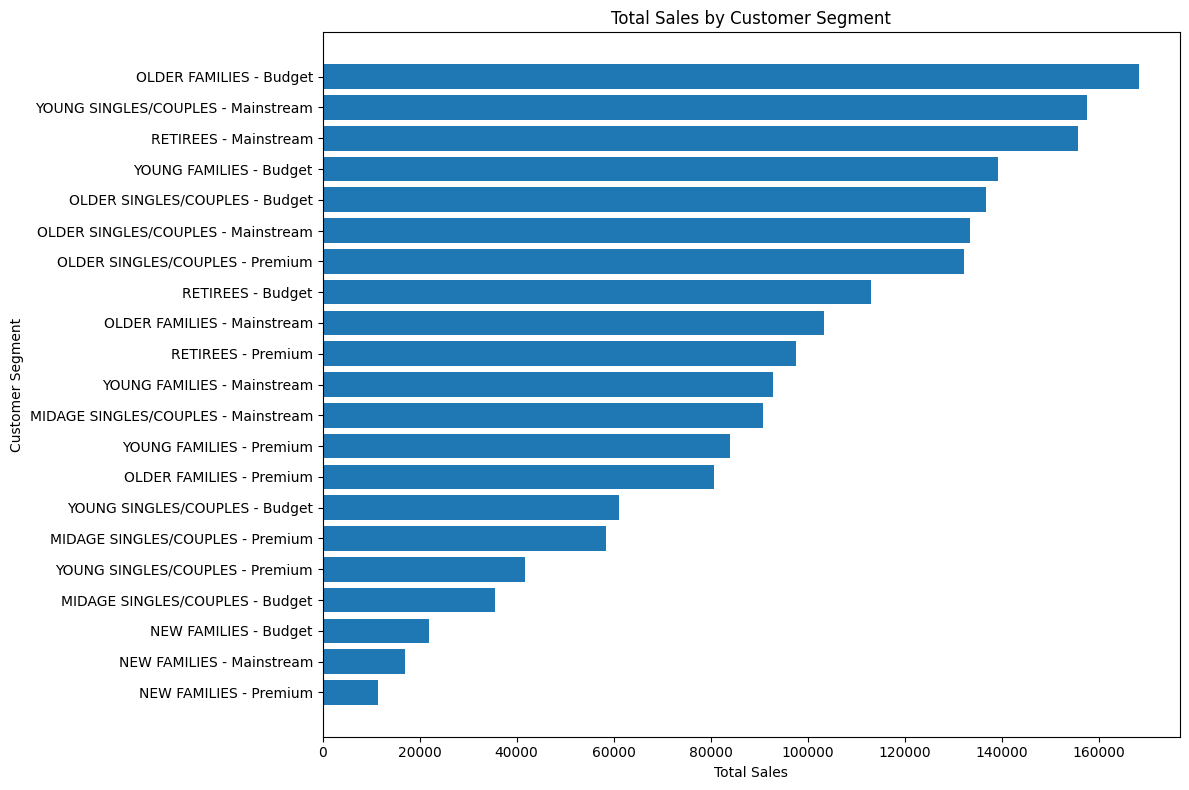

In [82]:
plt.figure(figsize=(12, 8))
plt.barh(sales_by_segment["SEGMENT"], sales_by_segment["TOT_SALES"])
plt.xlabel("Total Sales")
plt.ylabel("Customer Segment")
plt.title("Total Sales by Customer Segment")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The chart compares total sales across customer segments.

The highest-sales segment, `OLDER FAMILIES - Budget`, appears to be one of the most commercially important groups, as it contributes the greatest total revenue to the category.

## 19. Visualisation: average purchase frequency by customer segment

<Figure size 1200x800 with 0 Axes>

<BarContainer object of 21 artists>

Text(0.5, 0, 'Average Transactions per Customer')

Text(0, 0.5, 'Customer Segment')

Text(0.5, 1.0, 'Average Purchase Frequency by Customer Segment')

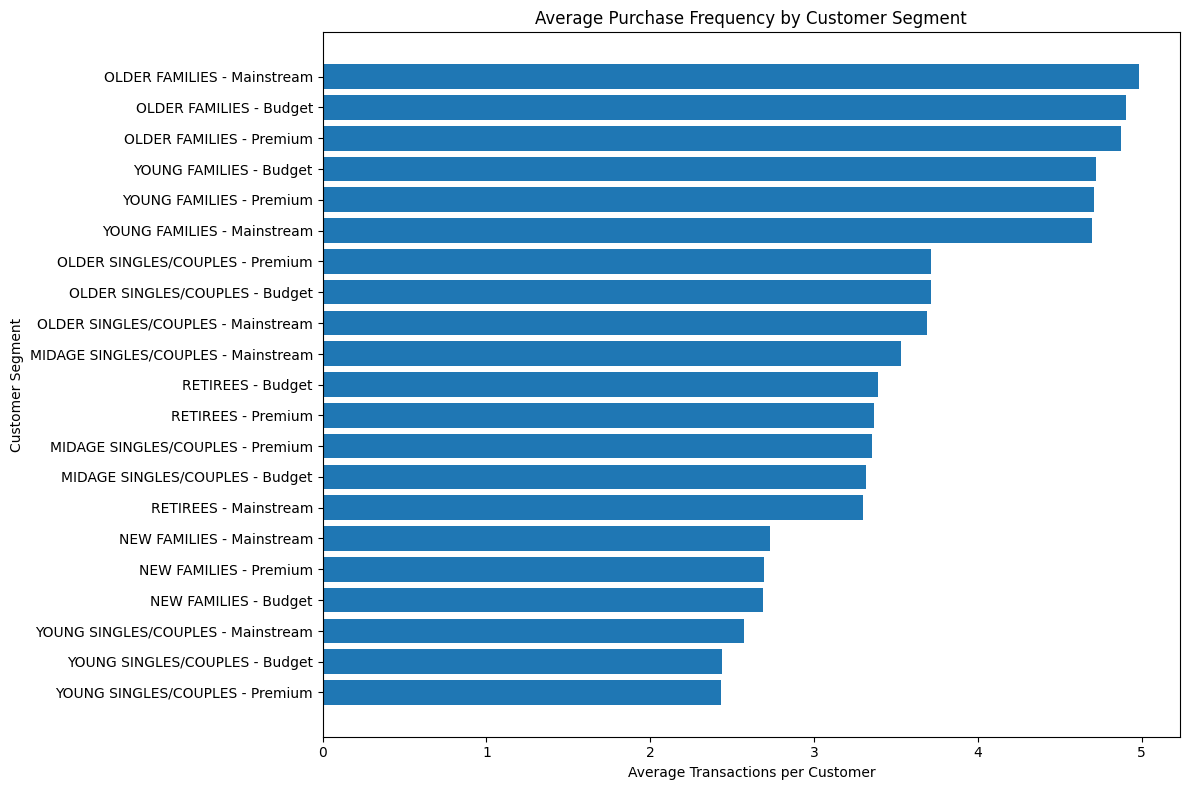

In [83]:
plt.figure(figsize=(12, 8))
plt.barh(avg_txn_by_segment["SEGMENT"], avg_txn_by_segment["TXN_COUNT"])
plt.xlabel("Average Transactions per Customer")
plt.ylabel("Customer Segment")
plt.title("Average Purchase Frequency by Customer Segment")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

This chart compares the average number of transactions per customer across segments.
Segments with higher values appear to shop more frequently, which may indicate stronger repeat purchasing behaviour. 
Interestingly, the chart shows three apparent groups. Among these, older and young families are the customers most frequent while new families and young singles/couples are the least frequent customers.

## 20. Visualisation: average units per transaction

<Figure size 1200x800 with 0 Axes>

<BarContainer object of 21 artists>

Text(0.5, 0, 'Average Units per Transaction')

Text(0, 0.5, 'Customer Segment')

Text(0.5, 1.0, 'Average Units per Transaction by Customer Segment')

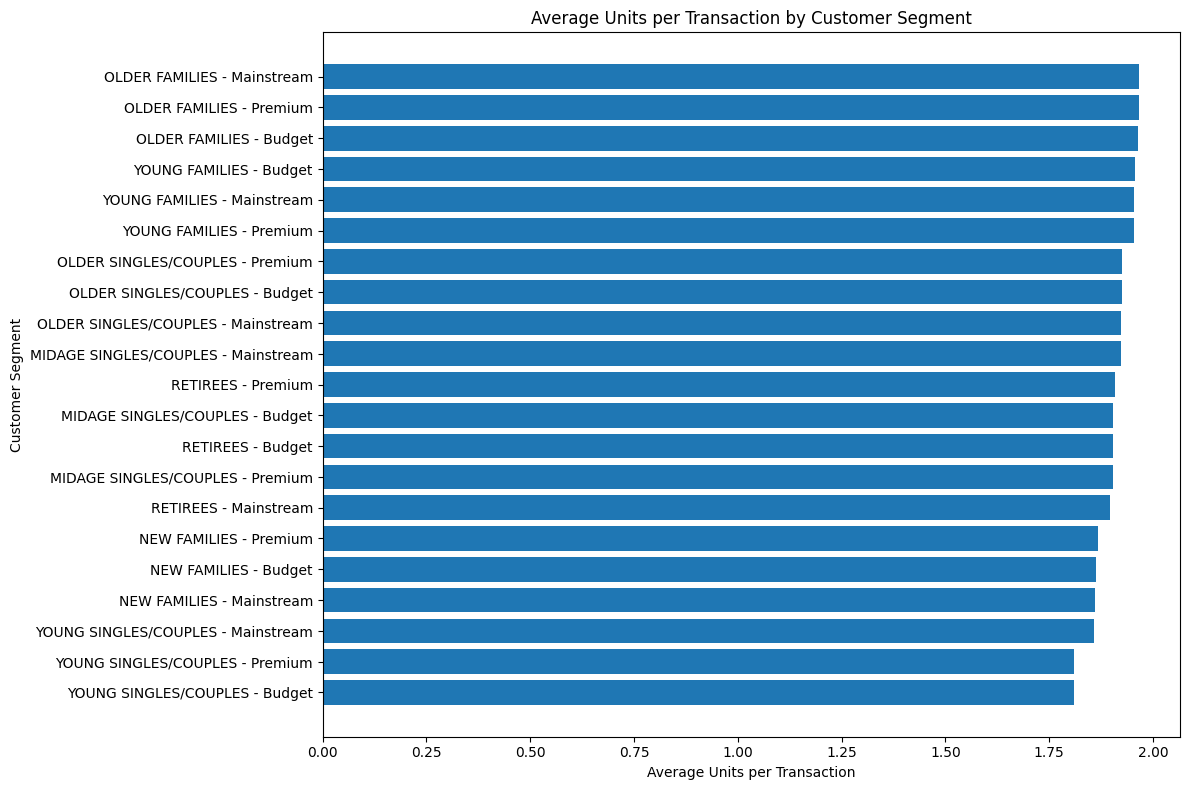

In [84]:
plt.figure(figsize=(12, 8))
plt.barh(avg_units_by_segment["SEGMENT"], avg_units_by_segment["TOTAL_UNITS_PER_TXN"])
plt.xlabel("Average Units per Transaction")
plt.ylabel("Customer Segment")
plt.title("Average Units per Transaction by Customer Segment")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

This chart shows the average number of units purchased per transaction for each customer segment.

Higher values suggest that customers in these segments tend to buy more items each time they shop.

## 21. Visualisation: average price per unit

<Figure size 1200x800 with 0 Axes>

<BarContainer object of 21 artists>

Text(0.5, 0, 'Average Price per Unit')

Text(0, 0.5, 'Customer Segment')

Text(0.5, 1.0, 'Average Price per Unit by Customer Segment')

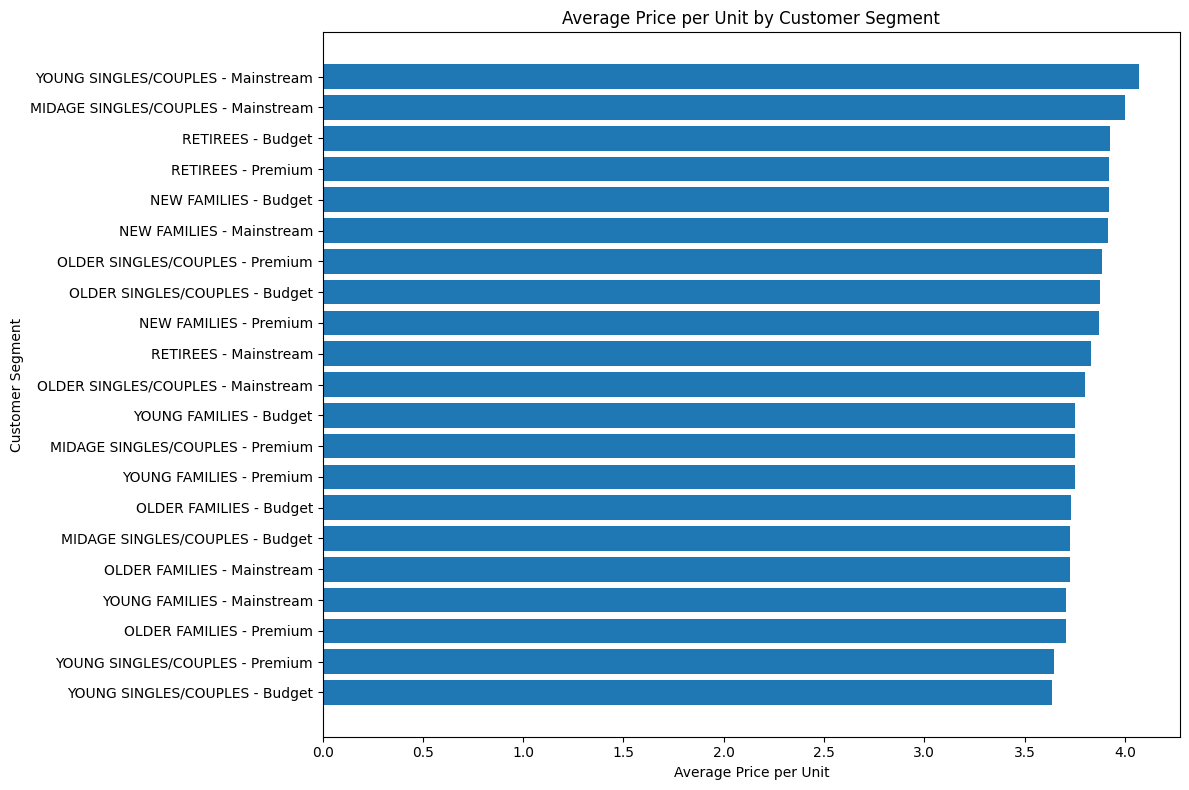

In [85]:
plt.figure(figsize=(12, 8))
plt.barh(avg_price_by_segment["SEGMENT"], avg_price_by_segment["PRICE_PER_UNIT"])
plt.xlabel("Average Price per Unit")
plt.ylabel("Customer Segment")
plt.title("Average Price per Unit by Customer Segment")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

This chart shows the average number of units purchased per transaction for each customer segment.

Higher values suggest that customers in these segments tend to buy more items each time they shop.

## 22. Identify top-performing customer segments

In [86]:
sales_by_segment.head(5)

,LIFESTAGE,PREMIUM_CUSTOMER,TOT_SALES,SEGMENT
0,OLDER FAMILIES,Budget,168363.25,OLDER FAMILIES - Budget
1,YOUNG SINGLES/COUPLES,Mainstream,157621.60,YOUNG SINGLES/COUPLES - Mainstream
2,RETIREES,Mainstream,155677.05,RETIREES - Mainstream
3,YOUNG FAMILIES,Budget,139345.85,YOUNG FAMILIES - Budget
4,OLDER SINGLES/COUPLES,Budget,136769.80,OLDER SINGLES/COUPLES - Budget


In [87]:
avg_txn_by_segment.head(5)

,LIFESTAGE,PREMIUM_CUSTOMER,TXN_COUNT,SEGMENT
0,OLDER FAMILIES,Mainstream,4.985164,OLDER FAMILIES - Mainstream
1,OLDER FAMILIES,Budget,4.905882,OLDER FAMILIES - Budget
2,OLDER FAMILIES,Premium,4.872855,OLDER FAMILIES - Premium
3,YOUNG FAMILIES,Budget,4.722430,YOUNG FAMILIES - Budget
4,YOUNG FAMILIES,Premium,4.711878,YOUNG FAMILIES - Premium


In [88]:
avg_price_by_segment.head(5)

,LIFESTAGE,PREMIUM_CUSTOMER,PRICE_PER_UNIT,SEGMENT
0,YOUNG SINGLES/COUPLES,Mainstream,4.071485,YOUNG SINGLES/COUPLES - Mainstream
1,MIDAGE SINGLES/COUPLES,Mainstream,4.000101,MIDAGE SINGLES/COUPLES - Mainstream
2,RETIREES,Budget,3.924883,RETIREES - Budget
3,RETIREES,Premium,3.921323,RETIREES - Premium
4,NEW FAMILIES,Budget,3.919251,NEW FAMILIES - Budget


## 23. Key insights

1. **`OLDER FAMILIES - Budget` generated the highest total sales.**  
   This suggests that this segment is one of the most commercially valuable customer groups in the dataset.

2. **`OLDER FAMILIES - Mainstream` showed one of the highest average purchase frequencies.**  
   This indicates that customers in this group may be more engaged and more likely to make repeat purchases.

3. **Basket size also varied across segments.**  
   `OLDER FAMILIES - Mainstream` purchased more units per transaction, suggesting larger basket sizes and stronger volume contribution per visit.

4. **Average unit price differed across customer segments.**  
   `YOUNG SINGLES/COUPLES - Mainstream` paid the highest average price per unit, suggesting that this segment may be less price-sensitive or may prefer relatively premium products.

## 24. Commercial recommendations

The analysis suggests that `OLDER FAMILIES - Budget` and `OLDER FAMILIES - Mainstream` should be prioritised in category growth strategy, as they contribute strongly through total sales, purchase frequency, and basket size.

In addition, `YOUNG SINGLES/COUPLES - Mainstream` should also be considered an important segment because this group pays the highest average price per unit.

Quantium could consider:
- targeting `OLDER FAMILIES` with promotions focused on value and multipack purchasing
- ensuring popular chip pack sizes are well stocked for family-oriented segments
- using more premium positioning and tailored promotions for `YOUNG SINGLES/COUPLES - Mainstream`
- improving merchandising and in-store activation based on segment-specific purchasing behaviour